In [ ]:
# Egy önvezető jármű eleinte és 3 másodpercig egyenletesen, 5 m/s sebességgel halad, 
# majd ez után elkezd gyorsítva-lassítva körözni. 
# Pontosabban: a kormányzása egyenletes szögsebességgel fordítja el irányát 12 s periódusidővel, 
# miközben sebességének nagysága 2,3 m/s amplitúdóval, 
# szinuszosan változik 7 s-os periódusidővel az 5 m/s-os érték körül.
#
#Ezért sebességét az alábbi egyenletek írják le:
#
#• t < 3 esetén:
#v_x = 5.0
#v_y = 0.0
#
#• t ≥ 3 esetén:
#φ(t) = (2π / 12) * (t - 3)
#v(t) = 5 + 2.3 * sin((2π / 7) * (t - 3))
#v_x(t) = v(t) * cos(φ(t))
#v_y(t) = v(t) * sin(φ(t))

In [2]:
import numpy as np    
import matplotlib.pyplot as plt
%matplotlib inline    
 
from fizinfo import *

def onvezeto_v(t):
    # Létrehozunk két csupa nullából álló tömböt, amik pontosan olyan hosszúak, mint az idő (t) tömbünk
    vx = np.zeros_like(t)
    vy = np.zeros_like(t)
    
    # --- 1. SZAKASZ: t < 3 (Egyenes haladás) ---
    maszk_egyenes = t < 3
    
    # Azokon a helyeken (indexeken), ahol a maszk True, beállítjuk a sebességeket
    vx[maszk_egyenes] = 5.0
    vy[maszk_egyenes] = 0.0
    
    # --- 2. SZAKASZ: t >= 3 (Kanyargós haladás) ---
    maszk_kanyar = t >= 3
    
    # Csak azokat az időpontokat vesszük ki, amik 3 másodpercnél nagyobbak
    t_kanyar = t[maszk_kanyar]
    
    # Kiszámoljuk a képleteket KIZÁRÓLAG ezekre az időpontokra (t_kanyar)
    phi = (2 * np.pi / 12) * (t_kanyar - 3)
    v_magn = 5 + 2.3 * np.sin((2 * np.pi / 7) * (t_kanyar - 3))
    
    # A kiszámolt értékeket beírjuk a vx és vy tömbök megfelelő helyeire
    vx[maszk_kanyar] = v_magn * np.cos(phi)
    vy[maszk_kanyar] = v_magn * np.sin(phi)
    
    # Végül összerakjuk a két elkészült vektort egyetlen mátrixszá, ahogy a jarmu_r(t)-nél is volt
    return np.array([vx, vy], dtype=np.float64)

In [3]:
# a) Ábrázolja a jármű pályáját az első 100 másodpercben, feltéve, hogy az origóból indult! (3 p)
jarmu=num_kinem(2)   # 2D kinematikai számítások
jarmu.set_time_range(0.0, 100.0, 0.01)

jarmu.set_v_fun(onvezeto_v)
jarmu.calc_v_to_r()
jarmu.calc_v_to_a()

#jarmu.plot_rcomp()

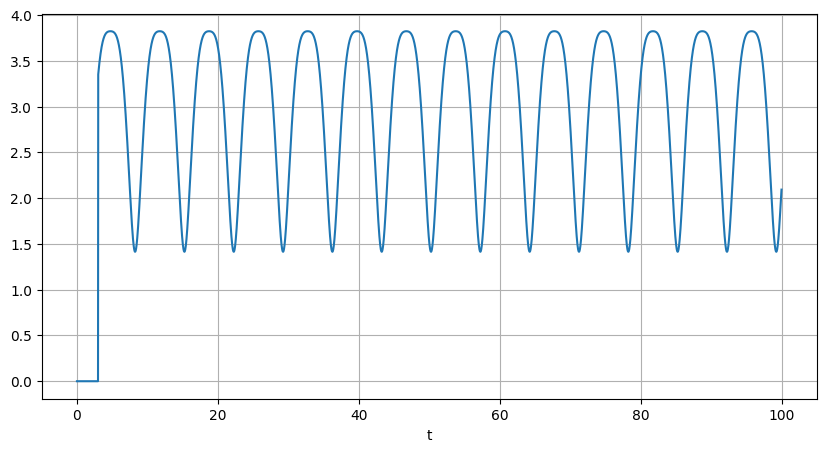

In [4]:
# b) Ábrázolja az autó gyorsulásának nagyságát az idő függvényében! (2 p)

jarmu.calc_v_to_a()
jarmu.calc_pathlength()
# Mivel a jarmunek van x és y irányú gyorsulasa ezért vektor abszolút érték kell
jarmu.a_abs = vect_abs(jarmu.a)

fig=plt.figure(figsize=(10,5))  
ax1=plt.subplot(111)

ax1.plot(jarmu.t,jarmu.a_abs)
ax1.set_xlabel('t')

ax1.grid()

In [5]:
# c) Határozza meg annak a téglalap alakú tesztpályának a minimális méreteit, 
# melyről nem fut le az autó a kísérlet során! (2 p)

# Kikeressük az X (0. oszlop) és Y (1. oszlop) koordináták minimumát és maximumát
x_min = jarmu.r[:, 0].min()
x_max = jarmu.r[:, 0].max()

y_min = jarmu.r[:, 1].min()
y_max = jarmu.r[:, 1].max()

# A téglalap méreteit a maximum és minimum értékek távolsága (különbsége) adja meg
szelesseg = x_max - x_min
magassag = y_max - y_min

print(f'A tesztpálya minimális mérete: {szelesseg:.2f} m széles és {magassag:.2f} m hosszú.')

A tesztpálya minimális mérete: 30.64 m széles és 23.52 m hosszú.


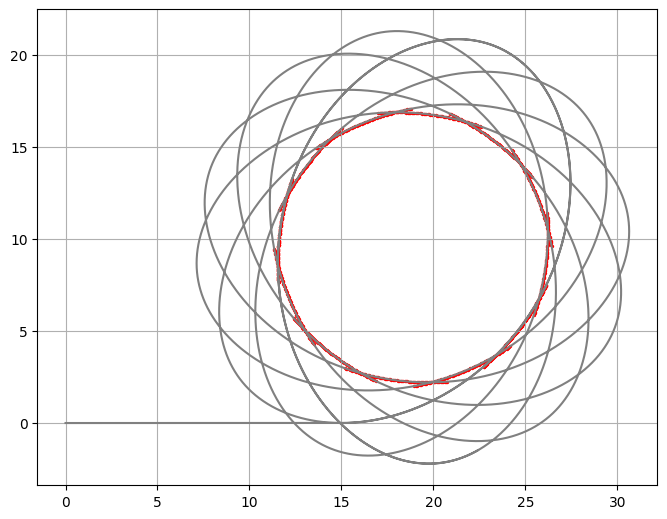

In [8]:
# d) Készítsen ábrát, melyen a jarmu pályája szürke, 
# és rajta pirossal be vannak jelölve azok a szakaszok, 
# ahol a centripetális gyorsulás nagyobb, mint a centripetális gyorsulás maximumának 98%-a. (3 p)

jarmu.calc_at_acp_Rinv()

gyors = jarmu.a_cp_abs.max() * 0.98 < jarmu.a_cp_abs

fig=plt.figure(figsize=(8,8))  
ax1=plt.subplot(111)

ax1.plot(jarmu.r[:,0], jarmu.r[:,1], color="grey")  # a pályagörbe
# a pályagörbe nagy a_cp-jű részeinél adatpontok:
ax1.scatter(jarmu.r[gyors,0], jarmu.r[gyors,1], color="red", s=2)  
ax1.set_aspect(aspect='equal')
ax1.grid()

t = 3 s után a legközelebbi pont időpontja: 84.74 s
t = 3 s után a legtávolabbi pont időpontja: 42.98 s


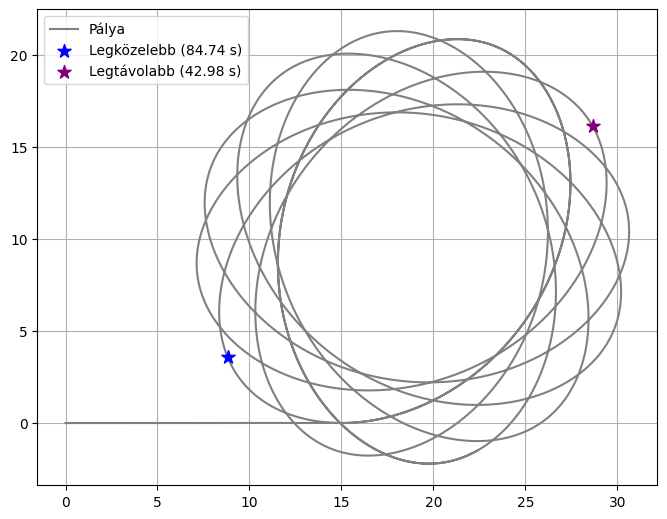

In [9]:
# e) Határozza meg azokat az időpontokat t = 3 s után, 
# melyekre az autó a legközelebb illetve a legtávolabb került a kiindulás helyétől 
# és jelölje be ezeket a test pályáján! (4p)

# 1. Kiszámoljuk az autó távolságát a kiindulóponttól (origótól) minden időpillanatban
# Mivel az origóból indult, a távolság megegyezik a pozícióvektor (r) abszolút értékével
tavolsagok = vect_abs(jarmu.r)

# 2. Készítünk egy maszkot, mert a feladat kifejezetten a "t = 3 s utáni" időpontokat kéri
utana_maszk = jarmu.t > 3.0

# 3. Megkeressük a legkisebb és legnagyobb távolság INDEXÉT a t > 3 szakaszon belül
# Az argmin() és argmax() nem az értéket, hanem annak a helyét (indexét) adja vissza
idx_legkozelebb = tavolsagok[utana_maszk].argmin()
idx_legtavolabb = tavolsagok[utana_maszk].argmax()

# 4. Kimásoljuk a pontos IDŐPONTOKAT a maszkolt időtömbből az indexek segítségével
t_kozel = jarmu.t[utana_maszk][idx_legkozelebb]
t_tavol = jarmu.t[utana_maszk][idx_legtavolabb]

# Kimásoljuk a pontos KOORDINÁTÁKAT is a maszkolt helytömbből az ábrázoláshoz
r_kozel = jarmu.r[utana_maszk][idx_legkozelebb]
r_tavol = jarmu.r[utana_maszk][idx_legtavolabb]

# Kiíratjuk az eredményeket az időpontokkal
print(f"t = 3 s után a legközelebbi pont időpontja: {t_kozel:.2f} s")
print(f"t = 3 s után a legtávolabbi pont időpontja: {t_tavol:.2f} s")

# --- ÁBRÁZOLÁS ---
fig = plt.figure(figsize=(8,8))  
ax1 = plt.subplot(111)

# A teljes pálya szürkével
ax1.plot(jarmu.r[:,0], jarmu.r[:,1], color="grey", label="Pálya")  

# Kék csillaggal jelöljük a legközelebbi pontot (s=100 a méret, zorder=5 hogy legfelül legyen)
ax1.scatter(r_kozel[0], r_kozel[1], color="blue", marker="*", s=100, zorder=5, 
            label=f"Legközelebb ({t_kozel:.2f} s)")

# lila csillaggal jelöljük a legtávolabbi pontot
ax1.scatter(r_tavol[0], r_tavol[1], color="purple", marker="*", s=100, zorder=5, 
            label=f"Legtávolabb ({t_tavol:.2f} s)")

ax1.set_aspect(aspect='equal')
ax1.legend()
ax1.grid()
plt.show()